# I- Nettoyage

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_excel("Sujet2.xlsx")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  4898 non-null   object
 1   age                      4887 non-null   object
 2   gender                   4891 non-null   object
 3   region                   4877 non-null   object
 4   subscription             4867 non-null   object
 5   device_type              4897 non-null   object
 6   nb_devices_used          4892 non-null   object
 7   time_on_platform         4887 non-null   object
 8   nb_sessions              4891 non-null   object
 9   avg_session_duration     4910 non-null   object
 10  premium_months           4892 non-null   object
 11  nb_friends               4900 non-null   object
 12  nb_groups                4884 non-null   object
 13  nb_pages_followed        4898 non-null   object
 14  nb_events_participated   4882 non-null  

,user_id,age,gender,region,subscription,device_type,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
count,4898,4887,4891,4877,4867,4897,4892,4887,4891,4910,...,4902,4899,4900,4889,4912,4911,4896,4895,4894,4878
unique,4869,107,29,58,37,52,17,4859,77,4878,...,126,93,108,64,1241,1544,4867,26,4864,4856
top,-1,49,F,Afrique,Free,Mobile,3,0,29,0,...,125,38,48,14,0,0,-1,4,-1,-1
freq,16,124,1594,1209,3304,1599,1647,15,379,19,...,187,325,275,475,523,20,16,1005,16,14


In [ ]:
#nettoyer 'user_id'
df['user_id']=pd.Series(range(1,len(df)+1), dtype=int)

In [ ]:
#nettoyer 'age'
numeric_age = pd.to_numeric(df['age'],errors='coerce')
non_integer_age_rows=df[numeric_age.isna() & df['age'].notna()]
non_integer_age_rows
df['age'] = df['age'].astype(str)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'].unique()
#on remarque qu'il y'a des ages incohérents notament des ages supérieurs à 100
#on remarque aussi que ce sont des ages qui sont des multiples de 10 donc on peut se dire qu'il s'agissait à la base d'ages corrects auquels un zéro a été ajouté
#avec cette hypothèses on transforme les valeurs
df.loc[(df['age'].notna()) & (df['age']> 100), 'age'] = df.loc[(df['age'].notna()) & (df['age']>100), 'age'] / 10
df['age'] = df['age'].replace([-1,0],pd.NA)
df.loc[df['age']>100, 'age']=pd.NA
df['age'].unique()

array([21.0, 36.0, 24.0, 55.0, 35.0, 50.0, 62.0, 47.0, 41.0, 51.0, 46.0,
       nan, 34.0, 58.0, 31.0, 25.0, 57.0, 61.0, 42.0, 20.0, 29.0, 52.0,
       63.0, 23.0, 30.0, 64.0, 60.0, 54.0, 48.0, 56.0, 27.0, 37.0, 40.0,
       45.0, 39.0, 38.0, 22.0, 44.0, 28.0, 49.0, 53.0, 19.0, 43.0, 32.0,
       59.0, 33.0, <NA>, 18.0, 26.0], dtype=object)

In [ ]:
#nettoyer 'genre'
def nettoie_genre(v):
    if pd.isna(v): return 'Autre'
    s = str(v).strip().lower()
    if s in ['h', 'H', 'homme']:       return 'Homme'
    if s in ['f', 'F', 'femme']:          return 'Femme'
    if 'autre' in s:  return 'Autre'
    return 'Autre'

df['gender'] = df['gender'].apply(nettoie_genre).str.title()
df['gender'].unique()

array(['Autre', 'Homme', 'Femme'], dtype=object)

In [ ]:
#nettoyer 'region'
def nettoie_region(value):
    if pd.isna(value) or value == '':
        return pd.NA

    s = str(value).strip().lower()
    s = s.replace('###', '').replace('??', '').replace('???', '').replace('?', '')

    if 'europe' in s:
        return 'Europe'
    elif any(word in s for word in ['ameri', 'america', 'amérique']):
        return 'Amerique'
    elif any(word in s for word in ['asi', 'asie', 'asia']):
        return 'Asie'
    elif any(word in s for word in ['afri', 'afrique', 'africa']):
        return 'Afrique'
    elif 'undefined' in s:
        return pd.NA
    else:
        return pd.NA

df['region'] = df['region'].apply(nettoie_region).str.title()
df['region'].unique()

array(['Europe', 'Amerique', 'Asie', 'Afrique', <NA>], dtype=object)

In [ ]:
#nettoyer 'subscription'
def nettoie_subscription(value):
    if pd.isna(value) or value == '':
        return pd.NA

    s = str(value).strip().lower()
    s = s.replace('###', '').replace('??', '').replace('?', '')

    if 'free' in s:
        return 'Free'
    if 'premium' in s:
        return 'Premium'
    if 'undef' in s:
        return pd.NA

df['subscription'] = df['subscription'].apply(nettoie_subscription).str.title()
df['subscription'].unique()

array([None, 'Premium', 'Free', <NA>], dtype=object)

In [ ]:
#nettoyer 'device_type'
def nettoie_device_type(value):
    if pd.isna(value) or str(value).strip() in ['', '???', 'undefined']:
        return pd.NA

    s = str(value).strip().lower()
    s = s.replace('###', '').replace('??', '').replace('?', '')

    if 'desktop' in s:
        return 'Desktop'
    elif 'tablet' in s:
        return 'Tablet'
    elif 'mobile' in s:
        return 'Mobile'
    else:
        return pd.NA

df['device_type'] = df['device_type'].apply(nettoie_device_type).str.title()
df['device_type'].unique()

array(['Desktop', 'Tablet', 'Mobile', <NA>], dtype=object)

In [ ]:
#Enlever tout ce qui n'est pas numérique dans les colonnes numériques
numeric_cols = ['age', 'nb_devices_used', 'time_on_platform', 'nb_sessions','avg_session_duration', 'premium_months', 'nb_friends', 'nb_groups',
                'nb_pages_followed', 'nb_events_participated', 'nb_searches','nb_notifications_opened', 'nb_saved_posts', 'nb_reports',
                'nb_blocked_users', 'photos_posted', 'videos_posted', 'stories_posted','travels_shared', 'countries_visited', 'likes', 'shares',
                'comments_written', 'reactions_given', 'reactions_received','messages_sent', 'messages_received', 'ads_clicked', 'video_views',
                'engagement_score', 'churn_risk', 'satisfaction', 'geo_lat', 'geo_lon']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True),errors='coerce')

In [ ]:
#Enlever les valeurs négatives dans les colonnes qui ne peuvent pas prendre de valeurs négatives
non_neg_cols = ['nb_devices_used', 'nb_sessions', 'premium_months', 'nb_friends', 'nb_groups','nb_pages_followed', 'nb_events_participated', 'nb_searches',
                   'nb_notifications_opened', 'nb_saved_posts', 'nb_reports', 'nb_blocked_users','photos_posted', 'videos_posted', 'stories_posted', 'travels_shared',
                   'countries_visited', 'likes', 'shares', 'comments_written', 'reactions_given','reactions_received', 'messages_sent', 'messages_received', 'ads_clicked',
                   'video_views','time_on_platform']
for col in non_neg_cols:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

In [ ]:
#Les valeurs dans nb_devices_used sont peu probables. Qu'un seul utilisateur se connecte avec 10, 20, 30 appareils est plutot impossible
#(dans un échantillon de 5000 utilisateurs).
#Vu qu'on a 3 device_type on peut considérer que certaines personnes ont deux fois le même appareil
#on fait donc le choix de plafonner les nombre d'appareil par utilisateur à 6
df['nb_devices_used'] = df['nb_devices_used'].where(df['nb_devices_used'].between(0,6))
df['nb_devices_used'].describe()

,nb_devices_used
count,4875.000000
mean,2.006564
std,0.830258
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,3.000000


In [ ]:
#une session dure au moins 30s
df['avg_session_duration'] = df['avg_session_duration'].mask((df['avg_session_duration'] < 0.5), pd.NA)
df['avg_session_duration'].describe()

,avg_session_duration
count,4872.000000
mean,5.196311
std,3.522704
min,0.504444
25%,3.981621
50%,5.047116
75%,6.048068
max,82.217581


In [ ]:
#on va plafonner les valeurs de premium_months à 120(10ans) en se disant que le plateforme n'est pas active depuis plus longtemps que ça
df['premium_months'] = df['premium_months'].where(df['premium_months'] <= 120 , pd.NA)
df['premium_months'].describe()

,premium_months
count,4891.000000
mean,5.533020
std,10.161653
min,0.000000
25%,0.000000
50%,0.000000
75%,7.000000
max,110.000000


In [ ]:
#Mettre les coordonées dans des intervalles cohérents
df['geo_lat']=df['geo_lat'].clip(lower=-90, upper=90)
df['geo_lon']=df['geo_lon'].clip(lower=-180, upper=180)

#II-Analyse

In [ ]:
# on importe la bibliothèque nécessaire aux représentation graphiques : matplotlib
from matplotlib.pyplot import *
import matplotlib.pyplot as plt

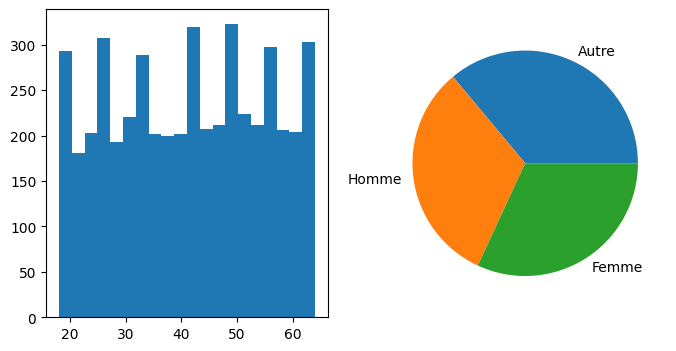

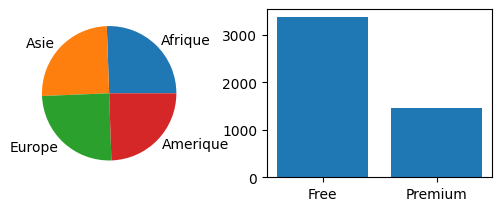

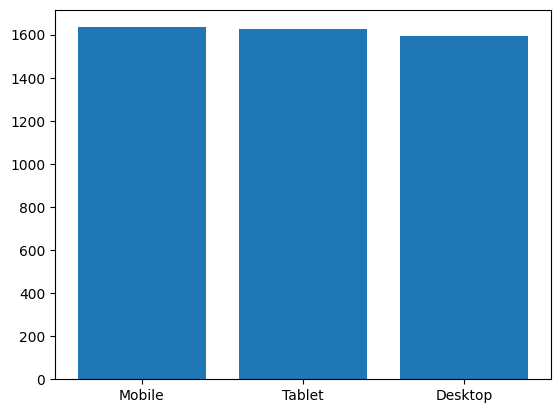

In [ ]:
#observons les données relatifs aux utilisateurs
figure(figsize=(8,4))
subplot(121)
hist(df['age'],bins=20, label=df['age'].unique())
subplot(122)
pie(df['gender'].value_counts(), labels=df['gender'].unique())
show()
subplot(221)
pie(df['region'].value_counts(), labels=df['region'].value_counts().index)
subplot(222)
bar(df['subscription'].value_counts().index, df['subscription'].value_counts().values)
show()
bar(df['device_type'].value_counts().index, df['device_type'].value_counts().values)
show()

/tmp/ipykernel_4231/905635467.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  europe_median = europe_data.groupby('age_bin')['age'].median()
/tmp/ipykernel_4231/905635467.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  asie_median   = asie_data.groupby('age_bin')['age'].median()


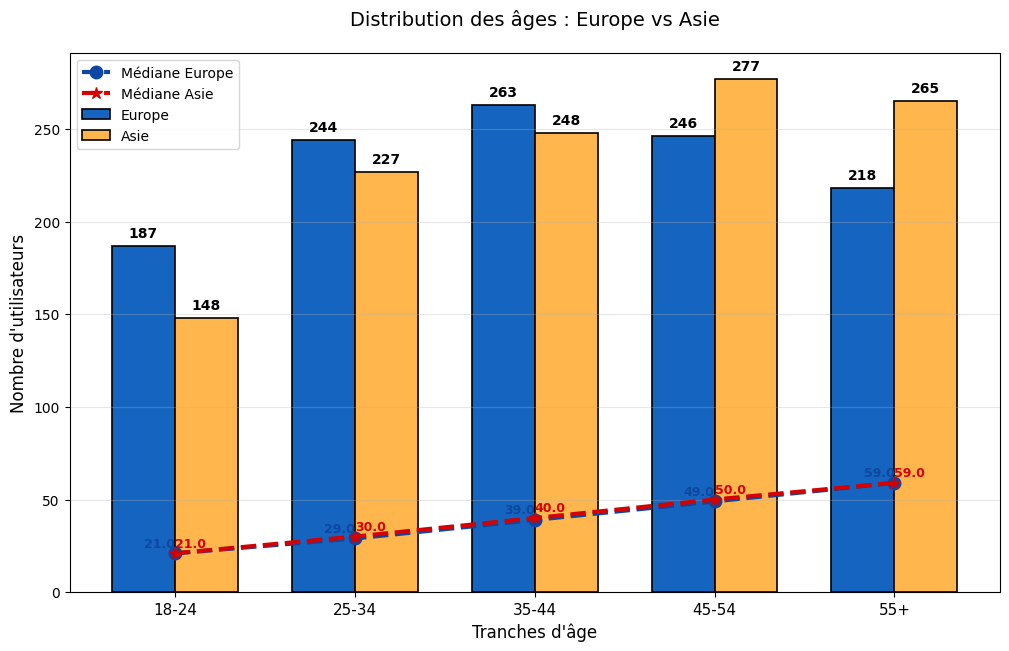

In [ ]:
#Graphique 1 : comparaison de l'âge des utilisateurs en Europe et en Asie
Europe= df[df['region'].str.contains('Europe', case=False, na=False)]['age'].dropna()
Asie  = df[df['region'].str.contains('Asie', case=False, na=False)]['age'].dropna()

bins = [18, 25, 35, 45, 55, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']

europe = pd.cut(Europe, bins=bins, labels=labels, right=False).value_counts().sort_index()
asie = pd.cut(Asie, bins=bins, labels=labels, right=False).value_counts().sort_index()

x = range(len(labels))
width = 0.35
plt.figure(figsize=(12, 7))
bars_eu = plt.bar([i - width/2 for i in x], europe, width=width,label='Europe', color='#1565C0', edgecolor='black', linewidth=1.2)
bars_as = plt.bar([i + width/2 for i in x], asie, width=width,label='Asie', color='#FFB74D', edgecolor='black', linewidth=1.2)

for bar in bars_eu:
    haut = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, haut + 3, f'{int(haut)}',ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_as:
    haut = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, haut + 3, f'{int(haut)}',ha='center', va='bottom', fontsize=10, fontweight='bold')

europe_data = df[df['region'].str.contains('Europe', case=False, na=False)].copy()
asie_data   = df[df['region'].str.contains('Asie', case=False, na=False)].copy()
europe_data['age_bin'] = pd.cut(europe_data['age'], bins=bins, labels=labels, right=False)
asie_data['age_bin']   = pd.cut(asie_data['age'], bins=bins, labels=labels, right=False)

europe_median = europe_data.groupby('age_bin')['age'].median()
asie_median   = asie_data.groupby('age_bin')['age'].median()


plt.plot(x, europe_median, color='#0D47A1', linestyle='--', linewidth=3,marker='o', markersize=9, label='Médiane Europe', zorder=5)
plt.plot(x, asie_median, color='#D50000', linestyle='--', linewidth=3,marker='*', markersize=9, label='Médiane Asie', zorder=5)

for i, med in enumerate(europe_median):
    plt.text(x[i] , med + 1.8, f'{med:.1f}', ha='right', va='bottom', fontsize=9, fontweight='bold',color='#0D47A1')
for i, med in enumerate(asie_median):
    plt.text(x[i] , med + 1.8, f'{med:.1f}',ha='left', va='bottom', fontsize=9, fontweight='bold',color='#D50000')

plt.title('Distribution des âges : Europe vs Asie', fontsize=14, pad=20)
plt.xlabel('Tranches d\'âge', fontsize=12)
plt.ylabel('Nombre d\'utilisateurs', fontsize=12)
plt.xticks(x, labels, fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

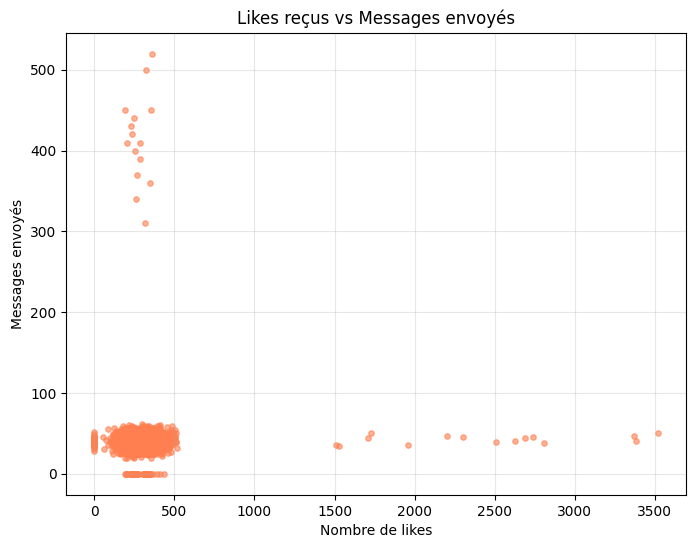

In [ ]:
# graphique bonus : compaison du nombre de messages envoyés en fonction du nombre de likes obtenus (ne pas prendre en compte)
plt.figure(figsize=(8, 6))
plt.scatter(df['likes'], df['messages_sent'], alpha=0.6, color='coral', s=15)
plt.title('Likes reçus vs Messages envoyés')
plt.xlabel('Nombre de likes')
plt.ylabel('Messages envoyés')
plt.grid(True, alpha=0.3)
plt.show()

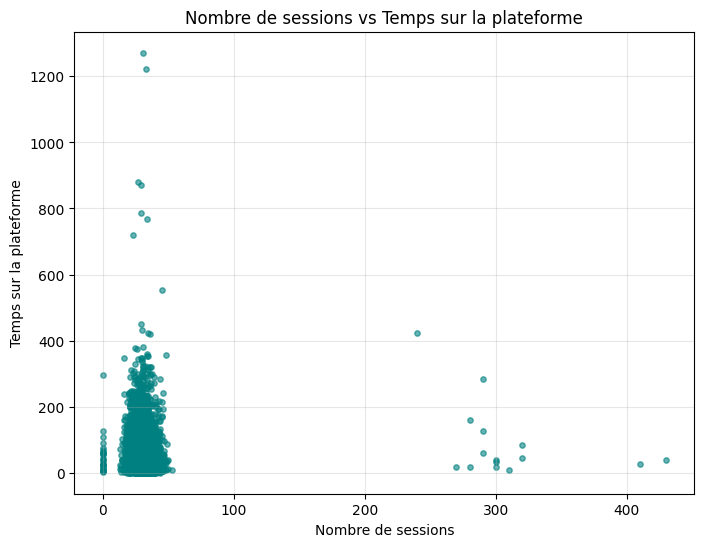

In [ ]:
# bonus : comparaison du temps sur la plateforme en fonction du nombre de sessions (ne pas prendre en compte)
plt.figure(figsize=(8, 6))
x = pd.to_numeric(df['nb_sessions'],errors='coerce')
y = pd.to_numeric(df['time_on_platform'],errors='coerce')
plt.scatter(x, y, alpha=0.6, color='teal', s=15)
plt.title('Nombre de sessions vs Temps sur la plateforme')
plt.xlabel('Nombre de sessions')
plt.ylabel('Temps sur la plateforme')
plt.grid(True, alpha=0.3)
plt.show()

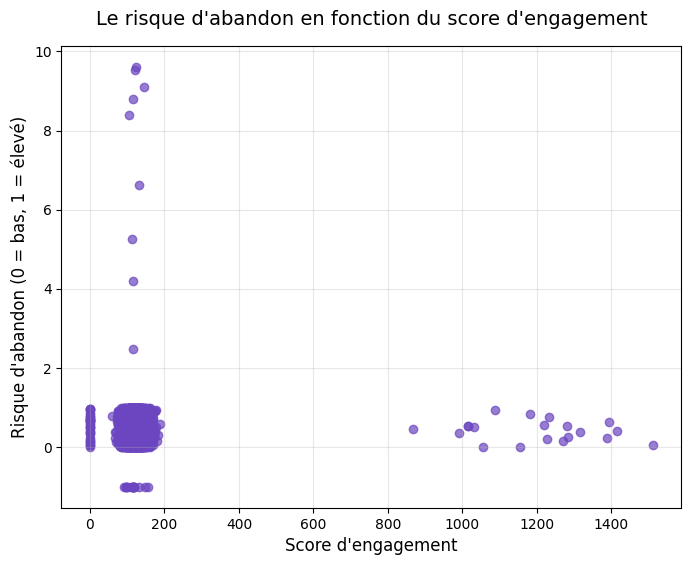

In [ ]:
# Graphique 2 : comparaison du risque d'abandon en fonction du score d'engagement
plt.figure(figsize=(8, 6))
plt.scatter(df['engagement_score'], df['churn_risk'],alpha=0.7,color='#6B46C0')
plt.title("Le risque d'abandon en fonction du score d'engagement", fontsize=14, pad=15)
plt.xlabel("Score d'engagement", fontsize=12)
plt.ylabel("Risque d'abandon (0 = bas, 1 = élevé)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

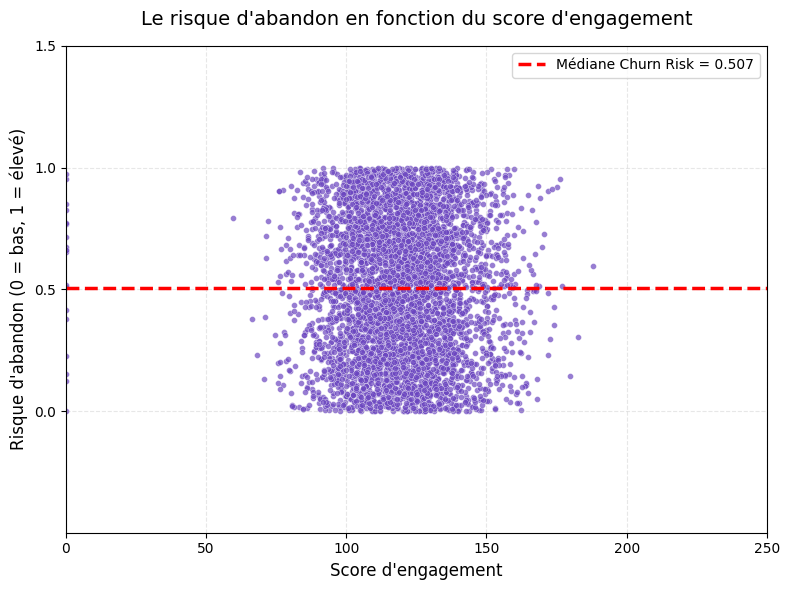

In [ ]:
#zoom sur la zone la plus concentrée
plt.figure(figsize=(8, 6))
plt.scatter(df['engagement_score'], df['churn_risk'],alpha=0.7,color='#6B46C0',s=18,edgecolor='white',linewidth=0.3)
median_churn = df['churn_risk'].median()
plt.axhline(y=median_churn, color='red', linestyle='--', linewidth=2.5,label=f'Médiane Churn Risk = {median_churn:.3f}')

# réduction de l'echelle
plt.xlim(0, 250)
plt.ylim(-0.5, 1)

plt.title("Le risque d'abandon en fonction du score d'engagement", fontsize=14, pad=15)
plt.xlabel("Score d'engagement", fontsize=12)
plt.ylabel("Risque d'abandon (0 = bas, 1 = élevé)", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.yticks([0, 0.5, 1.0, 1.5])
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_4231/1441994444.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = [group['video_views'].values for name, group in df_plot.groupby('age_group')]


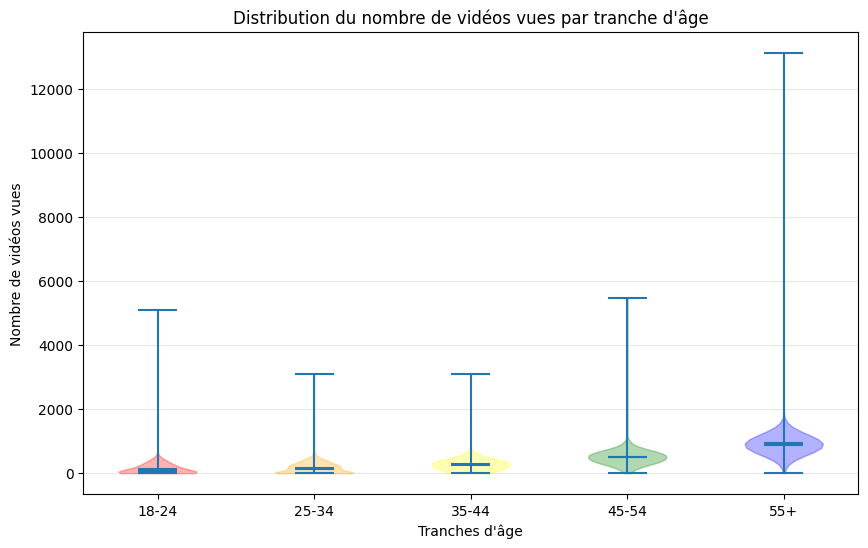

In [ ]:
# Graphique 3 : comparaison du nombre de vidéos vues en fonction de l'age
df['video_views'] = pd.to_numeric(df['video_views'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45, 55, 100],labels=['18-24', '25-34', '35-44', '45-54', '55+'], right=False)
df_plot = df.dropna(subset=['video_views', 'age_group'])
data = [group['video_views'].values for name, group in df_plot.groupby('age_group')]

plt.figure(figsize=(10, 6))
v=plt.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
plt.xticks(range(1, len(data)+1), df_plot['age_group'].cat.categories)
v['bodies'][0].set_facecolor('#FF0000')
v['bodies'][0].set_edgecolor('#FF0000')
v['bodies'][1].set_facecolor('#FFA500')
v['bodies'][1].set_edgecolor('#FFA500')
v['bodies'][2].set_facecolor('#FFFF00')
v['bodies'][2].set_edgecolor('#FFFF00')
v['bodies'][3].set_facecolor('#008000')
v['bodies'][3].set_edgecolor('#008000')
v['bodies'][4].set_facecolor('#0000FF')
v['bodies'][4].set_edgecolor('#0000FF')
plt.title('Distribution du nombre de vidéos vues par tranche d\'âge')
plt.xlabel('Tranches d\'âge')
plt.ylabel('Nombre de vidéos vues')
plt.grid(axis='y', alpha=0.3)
plt.show()

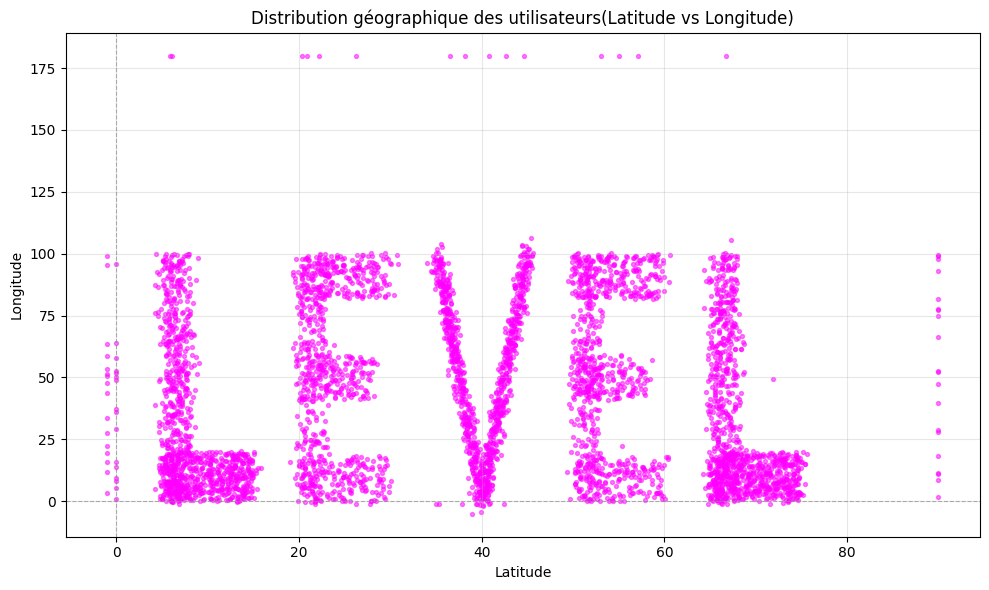

In [ ]:
#Visualisation de l'information supplémentaire: la latitude et la longitude
df['geo_lat'] = pd.to_numeric(df['geo_lat'], errors='coerce')
df['geo_lon'] = pd.to_numeric(df['geo_lon'], errors='coerce')
df_geo = df.dropna(subset=['geo_lat', 'geo_lon']).copy()

plt.figure(figsize=(10, 6))
plt.scatter(df_geo['geo_lat'], df_geo['geo_lon'], alpha=0.5, color='magenta', s=8)
plt.title('Distribution géographique des utilisateurs(Latitude vs Longitude)')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()